In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

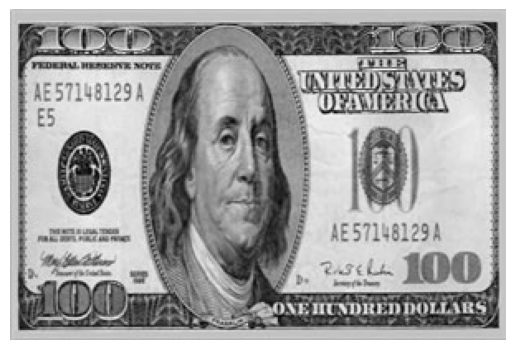

In [3]:
# 1. Histogram Equalization
img = cv.imread("/Users/ved/dip/images/img1-1.bmp", 0)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
freq = {}
rows, cols = img.shape

for row in range(rows):
    for col in range(cols):
        r = img[row][col]
        if r in freq:
            freq[r] += 1
        else:
            freq[r] = 1

for i in range(256):
    if i not in freq:
        freq[i] = 0

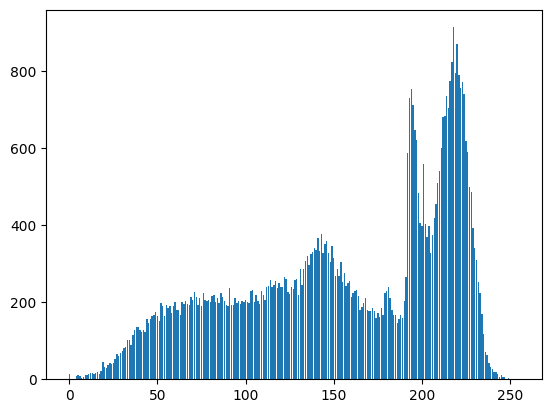

In [5]:
plt.bar(freq.keys(), freq.values())
plt.show()

In [6]:
total_pixels = rows*cols
df = pd.DataFrame({
    "Gray_levels" : list(freq.keys()),
    "Nk" : list(freq.values())
})

df["PDF"] = df["Nk"]/total_pixels
df["CDF"] = df["PDF"].cumsum()
df["Sk"] = df["CDF"]*255
df["New_Histogram"] = df["Sk"].round().astype(np.uint8)

equalized = np.zeros_like(img)
for row in range(rows):
    for col in range(cols):
        r = img[row][col]
        equalized[row][col] = df.loc[r, "New_Histogram"]

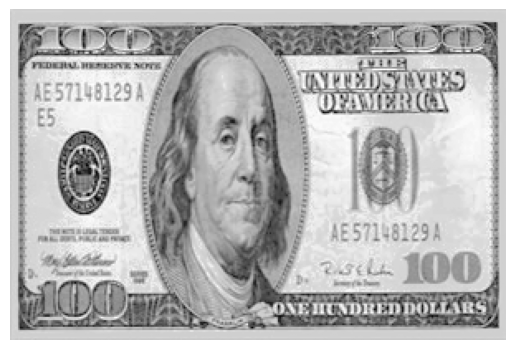

In [7]:
plt.imshow(equalized, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
equalized_freq = {}
rows, cols = equalized.shape

for row in range(rows):
    for col in range(cols):
        r = equalized[row][col]
        if r in equalized_freq:
            equalized_freq[r] += 1
        else:
            equalized_freq[r] = 1

for i in range(256):
    if i not in equalized_freq:
        equalized_freq[i] = 0

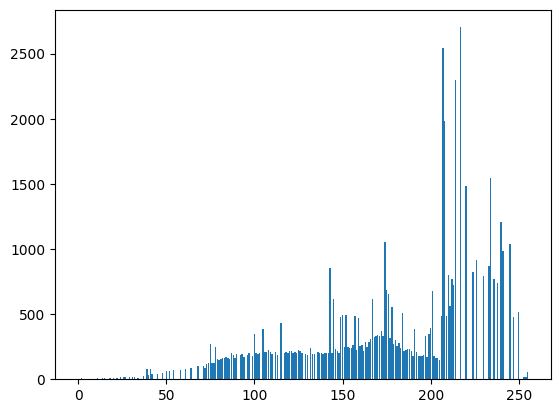

In [9]:
plt.bar(equalized_freq.keys(), equalized_freq.values())
plt.show()